In [1]:
using Catalyst: spatial_convert_err
include("../src/DiscreteStochasticSimulation.jl")
#include("../src/core/ssa.jl")
using .DiscreteStochasticSimulation
using Catalyst
using ProgressMeter 
ProgressMeter.ijulia_behavior(:clear)
using Plots
using Expokit
using SparseArrays
using DifferentialEquations 
using OrdinaryDiffEq
using JLD

┌ Warning: Replacing docs for `Main.DiscreteStochasticSimulation.FindLowestValuesPercent :: Union{Tuple{T}, Tuple{Vector{T}, Number}} where T` in module `Main.DiscreteStochasticSimulation`
└ @ Base.Docs docs/Docs.jl:243


## Lotka Volterra Chemical Reaction Network Definition using Catalyst.jl DSL

In [2]:
local k₁, k₂, k₃, X, Y
rn = @reaction_network begin
    k₁, X --> 2X
    k₂, X + Y --> 2Y
    k₃, Y --> 0
end

Model ##ReactionSystem#236
Unknowns (2):
  X(t)
  Y(t)
Parameters (3):
  k₁
  k₂
  k₃

## Plug in the reaction network structure into the discrete system wrapper

In [3]:
model = DiscreteStochasticSystem(rn);

## Define boundary condition function

Rectangular lattice simply means the solver won't consider states beyond the limits

In [4]:
 # define boundaries (rectangular lattice in this case)
bounds = (0, 500) #(lower limit, upper limit)
boundary_condition(x) = RectLatticeBoundaryCondition(x, bounds);

## Define initial state and place it in a set, then expand the space 

In [5]:
# define initial value and expand the space a bit 
U₀ = CartesianIndex(50, 100)

CartesianIndex(50, 100)

## Define a probability density vector over the initial state space and set the probability of initial value to 1 (rest to zero)

In [6]:
δt = 0.005
T = 0:δt:30

0.0:0.005:30.0

In [7]:
rates= [1.0, 0.005, 0.6]

3-element Vector{Float64}:
 1.0
 0.005
 0.6

## Run the simulation (sliding windows algorithm for fiite state projection)

In [81]:
# definine initial state set 
X = Set([U₀])
X = Expand!(X, model, rates, 0.0, boundary_condition, 10);

# initial probability vector (only for active states)
p₀ = zeros(X |> length)
p₀[DiscreteStochasticSimulation.FindElement(U₀, X)] = 1

global iter = 1
global pₜ = p₀
global sz = []
global m =[]
# time intrerval 
sol = Array{SparseMatrixCSC,1}(undef, length(T))
global p = Progress(length(T))

for t ∈ T
    
    #expand space and assemble matrix
    global X, pₜ = Expand!(X, pₜ, model, rates , t, boundary_condition, 4)

    push!(sz, length(X))
    A = MasterEquation(X, model, rates, boundary_condition, t)

    # solve system and normalize (using expokit (can also use numerical time steppers such as Runge-Kutta))
    global pₜ = expmv(δt, A, pₜ)

    # add add states in sparse arrays 
    I = [a[1] for a in X] 
    J = [a[2] for a in X] 
    sol[iter] = sparse(I, J, pₜ)

    # purge lowest 3% probability states (most will be zero; this is arbitrary as of now)
    X, pₜ = Purge!(X, pₜ, 3.0)
    push!(m, 1.0 - sum(pₜ) + sum(abs.(pₜ .- (pₜ ./ sum(pₜ)))))

    pₜ ./= sum(pₜ) # re-normalize the reduced state space
  
    # sparse matrix 
    iter+=1

    # comment following line if not using progress meter
    next!(p; showvalues = [
                           ("time (t)", t),
                           ("system size",sz[end]),
                           (" ", " "), 
                           ("system size (after purge)",length(pₜ)),
                           ("num pruned states", sz[end]-length(pₜ)),
                           ("pruned mass", m[end])])
end
#@save "sol_10_29.jld" sol
     

Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
  time (t):                   30.0
  system size:                434
   :                           
  system size (after purge):  339
  num pruned states:          95
  pruned mass:                0.0597352553740602


# Calculate FSP mean trajectory

In [86]:
cart2vec(x) = [Tuple(x)...]
T = 0:δt:30
sol_mean = @showprogress map(1:length(T)) do i
    I, J, V = findnz(sol[i])
    sum(hcat(I, J) .* V, dims=1)
end

x = @inbounds [sol_mean[i][1] for i ∈ 1:length(sol_mean)]
y = @inbounds [sol_mean[i][2] for i ∈ 1:length(sol_mean)]
fsp_mean = hcat(x, y);

# SSA solution

In [87]:
using JumpProcesses, StableRNGs

# Create an ODE that can be simulated.
u0_integers = [:X => 50, :Y => 100]
ps = [:k₁ => 1.0, :k₂ => 0.005, :k₃ => 0.6]
tspan = (0., 30.)

jinput = JumpInputs(rn, u0_integers, tspan, ps)
jprob = JumpProblem(jinput, rng = StableRNG(123))
jump_sol = solve(jprob)

n_trajs = 1000
ssa_trajs1=[]
@showprogress for i in 1:n_trajs 
    push!(ssa_trajs1, solve(jprob, SSAStepper()))
end;

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


In [88]:
uniform_time, ssa_mean = mean_trajectory(ssa_trajs1, T[1], T[end], length(T))

(LinRange{Float64}(0.0, 30.0, 6001), [49.9999999999993 99.9999999999986; 50.21042634387024 99.72226660758909; … ; 161.6924141865054 144.24161621395717; 161.83299999999994 144.3620000000001])

## Mean SSA Trajectory 

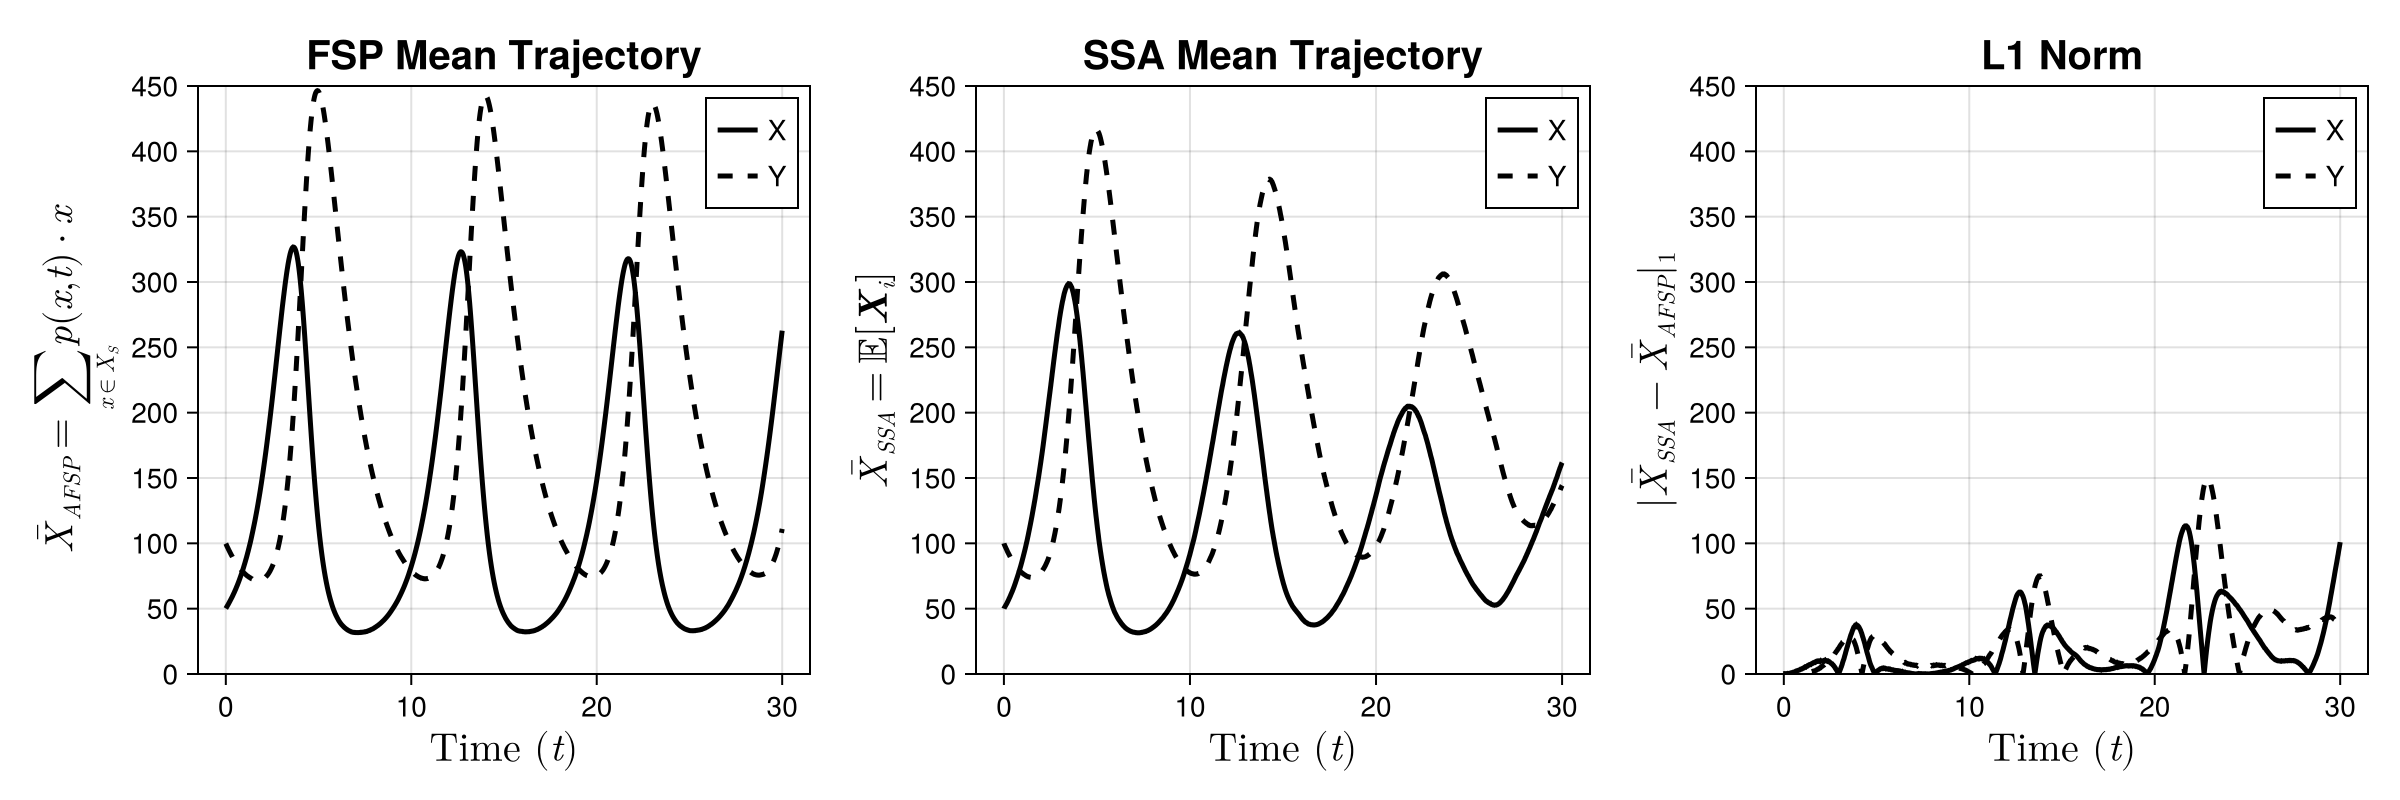

In [93]:
using CairoMakie

# Sample data: large 1000×4 matrix
n = length(T)  # Number of points
data1 = ssa_mean  # First dataset
data2 = fsp_mean  # Second dataset
data3 = abs.(fsp_mean .- ssa_mean) 
fig = Figure(size=(1200, 400))  # Set figure size

xlabel_size=20
ylabel_size=20
title_size = 20

# Create two subplots
ax2 = Axis(fig[1, 1], xlabel = L"Time $(t)$", ylabel = L"$\bar{X}_{AFSP}=\sum_{x \in X_S}p(x, t) \cdot x$", title = "FSP Mean Trajectory", titlesize=title_size,xlabelsize=xlabel_size, ylabelsize=ylabel_size)
ax1 = Axis(fig[1, 2], xlabel = L"Time $(t)$", ylabel = L"$\bar{X}_{SSA}=\mathbb{E}\left[\mathbf{X}_i\right]$", title = "SSA Mean Trajectory", titlesize=title_size, xlabelsize=xlabel_size, ylabelsize=ylabel_size)
ax3 = Axis(fig[1, 3], xlabel = L"Time $(t)$", ylabel = L"|\bar{X}_{SSA} - \bar{X}_{AFSP}|_1", title = "L1 Norm", titlesize=title_size,xlabelsize=xlabel_size, ylabelsize=ylabel_size)

CairoMakie.ylims!(ax1, 0,450) 
CairoMakie.ylims!(ax2, 0, 450) 
CairoMakie.ylims!(ax3, 0, 450) 



linestyles = [:solid, :dash]     # Different line styles
labels = ["X", "Y"]

# Choose marker frequency (plot markers only at these indices)
marker_step = 20
marker_indices = 1:marker_step:n

# Function to plot on a given axis
function plot_data!(ax, data; position = :rt, xlims=500)
    for i in 1:2
        # 1) Thin lines
        CairoMakie.lines!(ax, uniform_time, data[:, i];
            color     = :black,
            linestyle = linestyles[i],
            linewidth = 2.5,  # Thin lines
            label     = labels[i]
        )
    end
    axislegend(ax, position = position)  # Add legend
end

# Plot data in both subplots
plot_data!(ax1, data1)
plot_data!(ax2, data2)
plot_data!(ax3, data3; position=:rt)

save("lv.pdf", fig)
fig  # Display the figure

In [121]:
I1, J1, V1 = findnz(sol[1020])
states1 = [CartesianIndex(x...) for x ∈ eachrow(hcat(I1, J1))]
P1 = zeros(600, 600)
P1v = zeros(600, 600)
P1[states1] .= 1;
P1v[states1] .= V1;
     

I2, J2, V2 = findnz(sol[1040])
states2 = [CartesianIndex(x...) for x ∈ eachrow(hcat(I2, J2))]
P2 = zeros(600, 600)
P2v = zeros(600, 600)
P2[states2] .= 1;
P2v[states2] .= V2;
     

statesm = states1 ∪ states2
Pm = zeros(600, 600)
Pmv = zeros(600, 600)
Pm[statesm] .= 1;
Pmv[states2] .= V2;

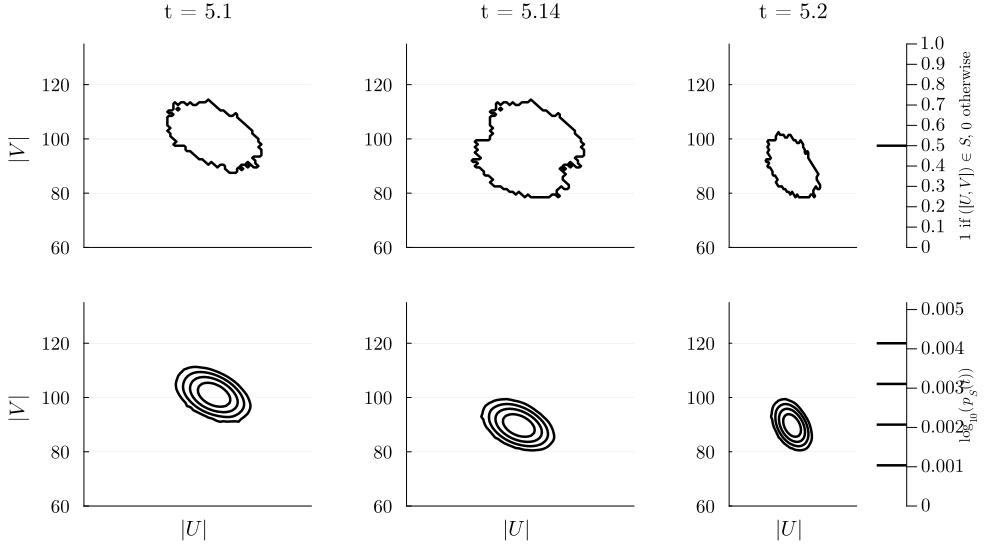

"/home/adiden/DiscreteStochasticSimulation/examples/toggle_switch_grid.pdf"

In [124]:
using Plots
using LaTeXStrings

# Initialize plot array
plots = []

top = [P1, Pm, P2]
bot = [P1v, Pmv, P2v]

T = LinRange(0, 30, length(sol))

# Iterate over selected solution indices
for (i, idx) in enumerate(points)
    

    # Active states contour (binary)
   
    colorbar_flag = (i == 3)  # Enable colorbar only for the rightmost column
    colorbar_ticks = (i == 1) ? ([0, 1], ["0", "1"]) : :auto  # Force first column to show only 0 and 1 ticks

    push!(plots, Plots.plot(Plots.contour(top[i], color=:black, fill=false, linewidth=2.5, 
                                          levels=1, 
                                          colorbar=colorbar_flag,
                                          colorbar_title=colorbar_flag ? L"1 if $([U, V]) \in S$, $0$ otherwise" : "",
                                          colorbar_ticks=colorbar_ticks)))
    push!(plots, Plots.plot(Plots.contour(bot[i], color=:black, fill=false, linewidth=2.5, 
                                          levels=4, 
                                          colorbar=colorbar_flag,
                                          colorbar_title=colorbar_flag ? L"\operatorname{log}_{10}(p_S(t))" : "")))
end

# Arrange plots in a 2x3 grid
plots = [plots...]
plots = [plots[1], plots[3], plots[5], plots[2], plots[4], plots[6]]

# Dynamic time labels
Plots.title!(plots[1], "")
Plots.title!(plots[2], "")
Plots.title!(plots[3], "")

# Axis labels
Plots.xlabel!(plots[4], L"|U|")
Plots.xlabel!(plots[5], L"|U|")
Plots.xlabel!(plots[6], L"|U|")

Plots.ylabel!(plots[1], L"|V|")
Plots.ylabel!(plots[4], L"|V|")

for p in plots
    Plots.xlims!(p, 400, 475)
    Plots.ylims!(p, 60, 135)
end

# Increase font size globally
default(fontfamily="Computer Modern", titlefontsize=14, tickfontsize=12, guidefontsize=14)

# Plot layout
p = Plots.plot(plots..., layout=grid(2, 3), size=(1000, 550), margin=5Plots.mm, xticks=[150, 350, 550], subtitle="My Subtitle")
display(p)
savefig("toggle_switch_grid.pdf")
